<a href="https://colab.research.google.com/github/diegogh1002/Estadistica/blob/main/limpieza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [46]:
df = pd.read_csv('csv.csv')
df.head()

,Marca temporal,Dirección de correo electrónico,¿En qué semestre te encuentras actualmente?,¿Qué carrera estudias?,¿Eres alumno regular?,Procedencia (dónde naciste),¿Tienes hermanos?,¿Cuál es la marca de tu teléfono?,Modelo del teléfono,Capacidad del teléfono,Plan o prepago del teléfono,Tiempo que llevas con tu teléfono,Tu teléfono es,Género,¿Trabajas?,Edad,¿Qué teléfono te gustaría tener?
0,3/9/2026 17:30:44,fespinozagarcia0105@gmail.com,Tercero,Ciencia de Datos,NaN,Estado de México,NaN,Honor,Honor x7a,128 GB,Plan,Entre 2 y 3 años,Nuevo,Mujer,Sí,21,NaN
1,3/9/2026 18:02:01,gisellemerino2702@gmail.com,Tercero,Ciencia de Datos,NaN,Estado de México,NaN,Apple,15 pro max,256 GB,Prepago,Entre 6 meses y 1 año,Nuevo,Mujer,No,21,NaN
2,3/9/2026 18:19:25,mildredcaravantes@gmail.com,Primero,Ciencia de Datos,NaN,Estado de México,NaN,Apple,iphone 16 pro max,256 GB,Plan,Entre 1 y 2 años,Nuevo,Mujer,No,20,NaN
3,3/9/2026 18:37:08,garcia.hernandez.edgar.alessandro@gmail.com,Tercero,Ciencia de Datos,NaN,CDMX,NaN,Apple,iPhone 16 Pro Max,256 GB,Plan,Entre 1 y 2 años,Nuevo,Hombre,No,19,NaN
4,3/9/2026 20:56:29,diegobus022@gmail.com,Tercero,Ciencia de Datos,NaN,Otro,NaN,Apple,iPhone 13 Pro max,512 GB,Prepago,Entre 1 y 2 años,Segunda mano,Hombre,No,19,NaN


**ANALISIS EXPLORATORIO EDA**

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 511 entries, 0 to 510
Data columns (total 17 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   Marca temporal                                511 non-null    object
 1   Dirección de correo electrónico               511 non-null    object
 2   ¿En qué semestre te encuentras actualmente?   511 non-null    object
 3   ¿Qué carrera estudias?                        511 non-null    object
 4   ¿Eres alumno regular?                         482 non-null    object
 5   Procedencia  (dónde naciste)                  511 non-null    object
 6   ¿Tienes hermanos?                             482 non-null    object
 7   ¿Cuál es la marca de tu teléfono?             511 non-null    object
 8   Modelo del teléfono                           511 non-null    object
 9   Capacidad del teléfono                        511 non-null    object
 10  Pl

In [51]:
descripcion = pd.DataFrame({
    "Variable": df.columns,
    "Tipo de dato": df.dtypes,
    "Tipo": ["Cualitativa" for _ in df.columns]
})
descripcion

,Variable,Tipo de dato,Tipo
Marca temporal,Marca temporal,object,Cualitativa
Dirección de correo electrónico,Dirección de correo electrónico,object,Cualitativa
¿En qué semestre te encuentras actualmente?,¿En qué semestre te encuentras actualmente?,object,Cualitativa
¿Qué carrera estudias?,¿Qué carrera estudias?,object,Cualitativa
¿Eres alumno regular?,¿Eres alumno regular?,object,Cualitativa
Procedencia (dónde naciste),Procedencia (dónde naciste),object,Cualitativa
¿Tienes hermanos?,¿Tienes hermanos?,object,Cualitativa
¿Cuál es la marca de tu teléfono?,¿Cuál es la marca de tu teléfono?,object,Cualitativa
Modelo del teléfono,Modelo del teléfono,object,Cualitativa
Capacidad del teléfono,Capacidad del teléfono,object,Cualitativa


In [52]:
df.head(10)
df.tail(10)

,Marca temporal,Dirección de correo electrónico,¿En qué semestre te encuentras actualmente?,¿Qué carrera estudias?,¿Eres alumno regular?,Procedencia (dónde naciste),¿Tienes hermanos?,¿Cuál es la marca de tu teléfono?,Modelo del teléfono,Capacidad del teléfono,Plan o prepago del teléfono,Tiempo que llevas con tu teléfono,Tu teléfono es,Género,¿Trabajas?,Edad,¿Qué teléfono te gustaría tener?
501,3/18/2026 15:10:31,danreyal06@gmail.com,Quinto,Ingeniería en Sistemas,No,CDMX,No,Samsung,S23 Ultra,256 GB,Prepago,Entre 1 y 2 años,Nuevo,Hombre,No,20,Samsung
502,3/18/2026 15:11:08,josemorales136909@gmail.com,Cuarto,Automotriz,Sí,Estado de México,Sí,Apple,14,128 GB,Plan,Entre 1 y 2 años,Nuevo,Hombre,Sí,20,Samsung
503,3/18/2026 15:12:40,angelurielmendozacruz@gmail.com,Cuarto,Ingeniería en Sistemas,Sí,CDMX,Sí,Apple,iPhone 14,128 GB,Prepago,Entre 6 meses y 1 año,Nuevo,Hombre,Sí,20,Apple
504,3/18/2026 15:14:49,apdr1997@gmail.com,Tercero,Ingeniería en Sistemas,Sí,Estado de México,Sí,Xiaomi,5522644535,512 GB,Prepago,Entre 6 meses y 1 año,Nuevo,Hombre,No,20,Samsung
505,3/18/2026 15:15:20,pikachussj300@gmail.com,Cuarto,Ingeniería en Sistemas,Sí,Estado de México,Sí,Samsung,Samsung S24 Ultra,256 GB,Plan,Menos de 6 meses,Nuevo,Hombre,No,19,Samsung
506,3/18/2026 16:05:40,gonzalez.leonardo.vv06@gmail.com,Tercero,Ciencia de Datos,Sí,Estado de México,Sí,Motorola,g71 5G,128 GB,Plan,Entre 2 y 3 años,Nuevo,Hombre,No,20,Motorola
507,3/18/2026 16:38:14,martinez.salinas.emiliano1@gmail.com,Sexto,Ciencia de Datos,Sí,CDMX,Sí,Apple,5611263561,256 GB,Plan,Entre 2 y 3 años,Nuevo,Hombre,Sí,20,Apple
508,3/18/2026 16:41:03,isaactoramd1@gmail.com,Sexto,Ciencia de Datos,No,Estado de México,Sí,Xiaomi,POCO X5 5G,256 GB,Plan,Entre 2 y 3 años,Nuevo,Hombre,No,23,Otra
509,3/18/2026 16:42:08,reginanovelo2003@gmail.com,Sexto,Ciencia de Datos,Sí,Estado de México,Sí,Apple,iPhone 16,256 GB,Plan,Entre 1 y 2 años,Nuevo,Mujer,Sí,22,Apple
510,3/18/2026 18:49:24,ruligamarons@gmail.com,Sexto,Ciencia de Datos,Sí,CDMX,No,Samsung,S21,256 GB,Prepago,Más de 3 años,Nuevo,Hombre,No,23,Samsung


In [53]:
total = len(df)

nulls = df.isnull().sum()
nulls_pct = (nulls / total) * 100

pd.DataFrame({
    "Nulos": nulls,
    "%": nulls_pct
})

,Nulos,%
Marca temporal,0,0.000000
Dirección de correo electrónico,0,0.000000
¿En qué semestre te encuentras actualmente?,0,0.000000
¿Qué carrera estudias?,0,0.000000
¿Eres alumno regular?,29,5.675147
Procedencia (dónde naciste),0,0.000000
¿Tienes hermanos?,29,5.675147
¿Cuál es la marca de tu teléfono?,0,0.000000
Modelo del teléfono,0,0.000000
Capacidad del teléfono,0,0.000000


In [54]:
df["Edad_num"] = pd.to_numeric(df["Edad"], errors='coerce')

df["Capacidad_num"] = df["Capacidad del teléfono"].str.extract(r'(\d+)')
df["Capacidad_num"] = pd.to_numeric(df["Capacidad_num"], errors='coerce')

In [55]:
num_df = df[["Edad_num","Capacidad_num"]]

estadisticos = pd.DataFrame({
    "Media": num_df.mean(),
    "Mediana": num_df.median(),
    "Moda": num_df.mode().iloc[0],
    "Varianza": num_df.var(),
    "DesvStd": num_df.std(),
    "Min": num_df.min(),
    "Max": num_df.max(),
    "Rango": num_df.max() - num_df.min(),
    "Q1": num_df.quantile(0.25),
    "Q2": num_df.quantile(0.5),
    "Q3": num_df.quantile(0.75)
})
estadisticos

,Media,Mediana,Moda,Varianza,DesvStd,Min,Max,Rango,Q1,Q2,Q3
Edad_num,20.042463,20.0,19.0,1.993938,1.412069,17.0,23.0,6.0,19.0,20.0,21.0
Capacidad_num,202.663405,128.0,256.0,16460.082560,128.296853,1.0,512.0,511.0,128.0,128.0,256.0


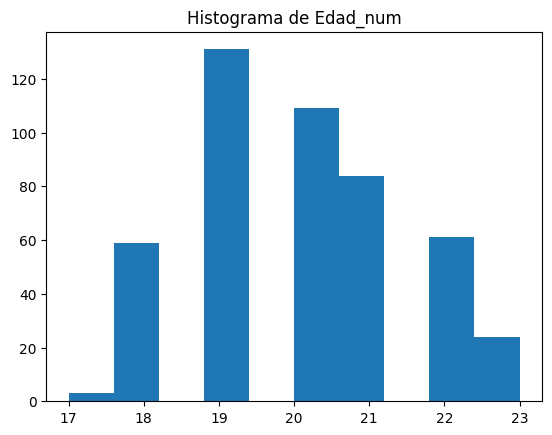

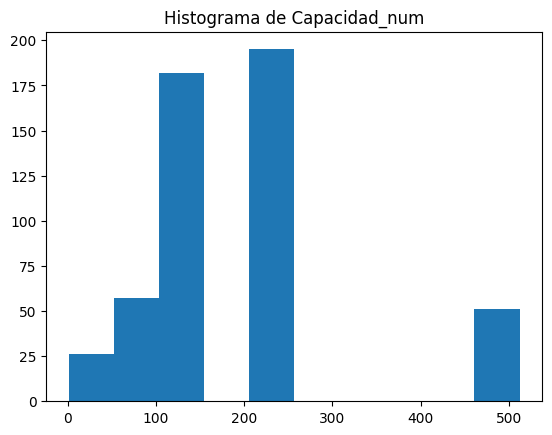

In [56]:
for col in num_df.columns:
    plt.figure()
    plt.hist(num_df[col].dropna(), bins=10)
    plt.title(f"Histograma de {col}")
    plt.show()

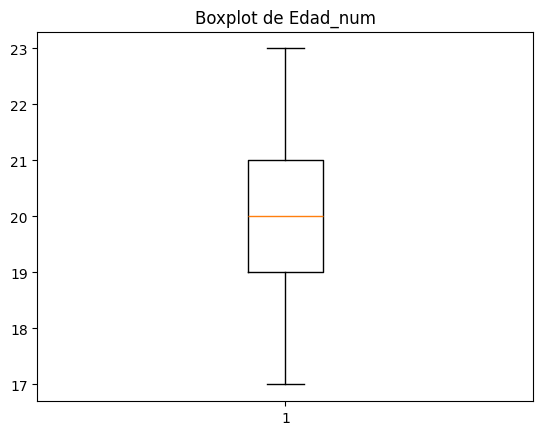

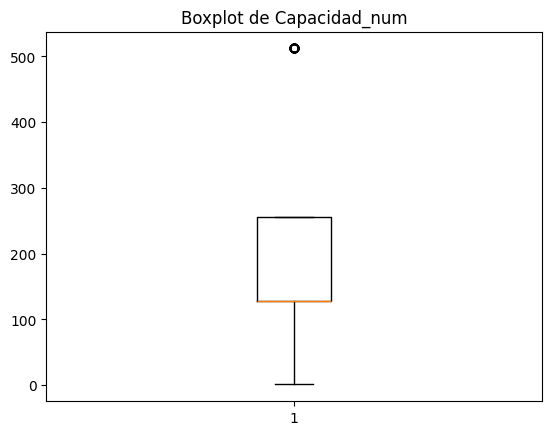

In [57]:
for col in num_df.columns:
    plt.figure()
    plt.boxplot(num_df[col].dropna())
    plt.title(f"Boxplot de {col}")
    plt.show()

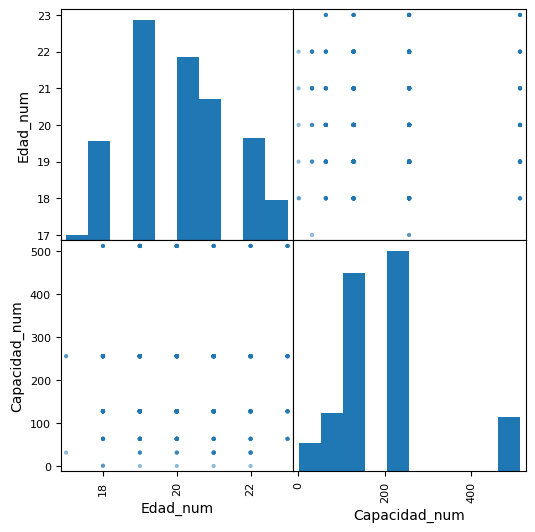

In [58]:
pd.plotting.scatter_matrix(num_df.dropna(), figsize=(6,6))
plt.show()

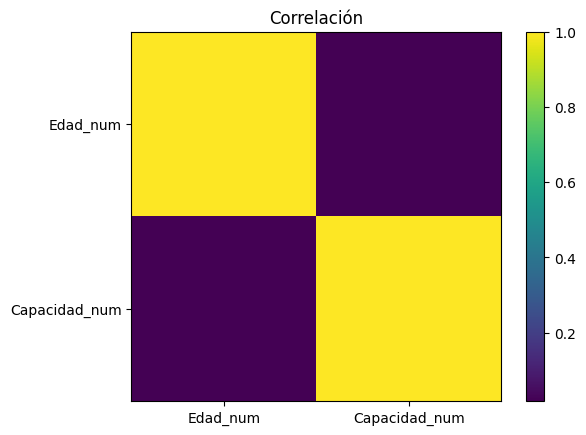

In [59]:
corr = num_df.corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlación")
plt.show()

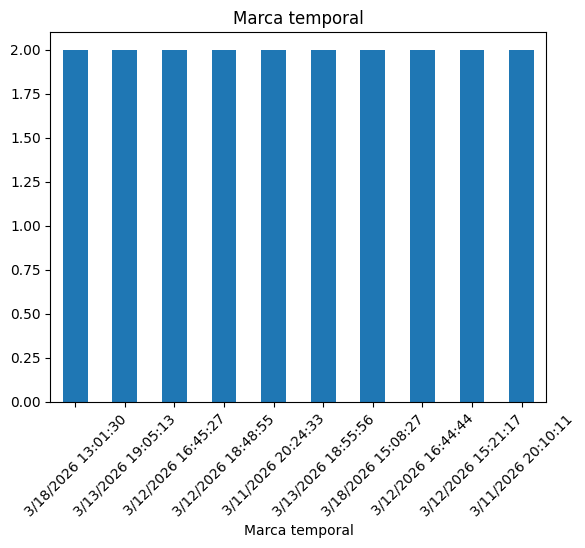

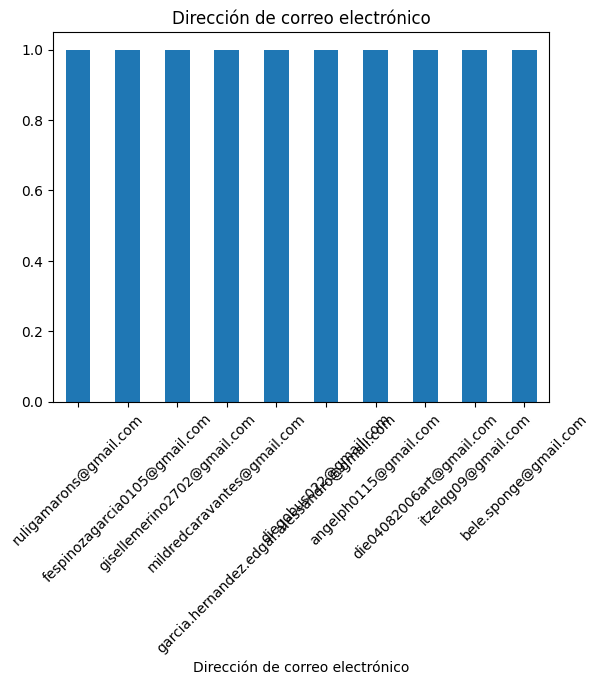

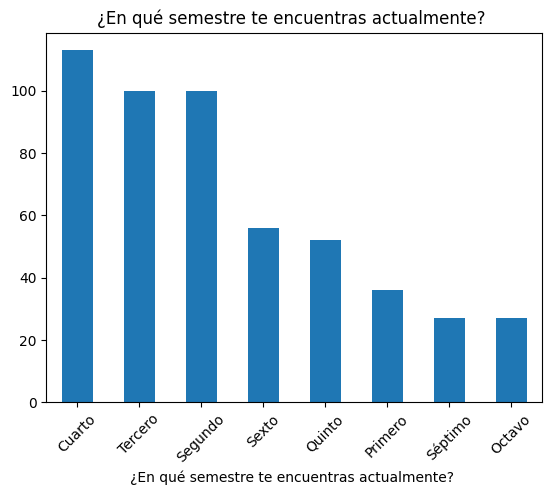

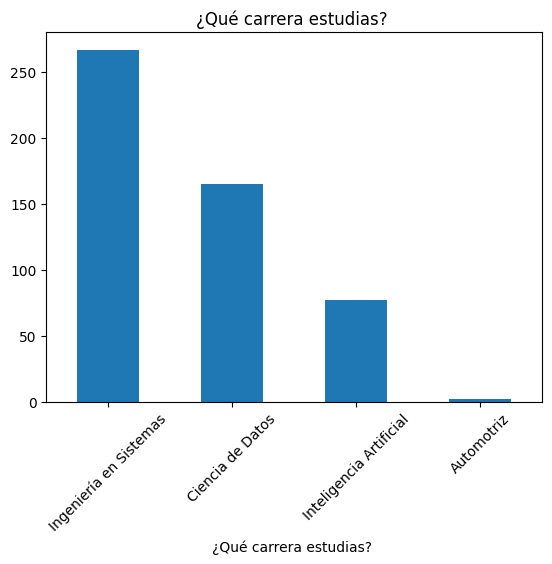

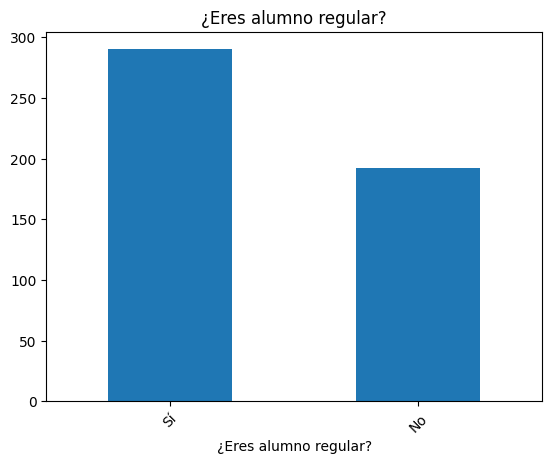

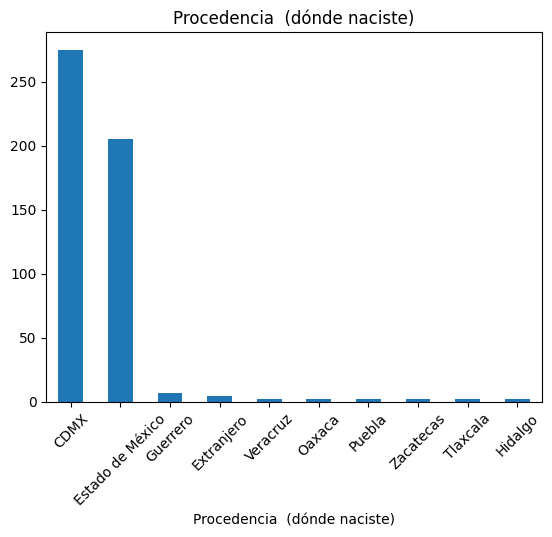

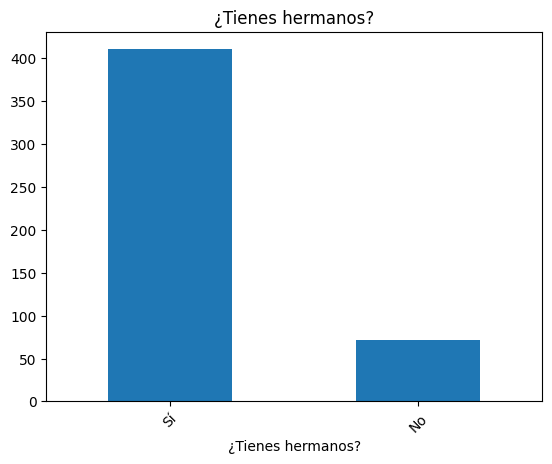

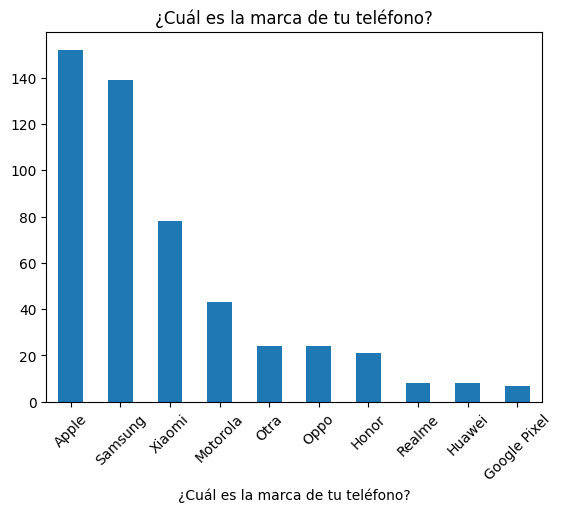

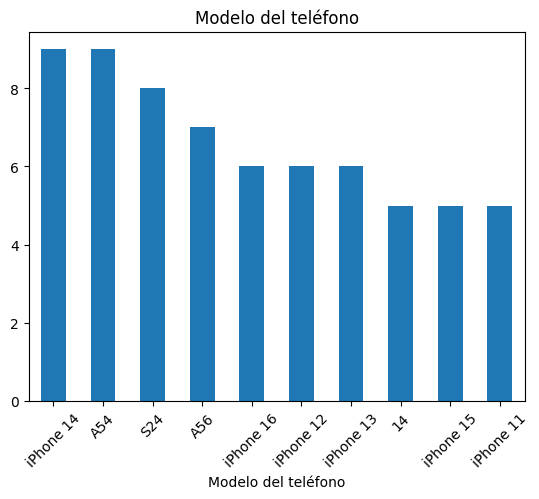

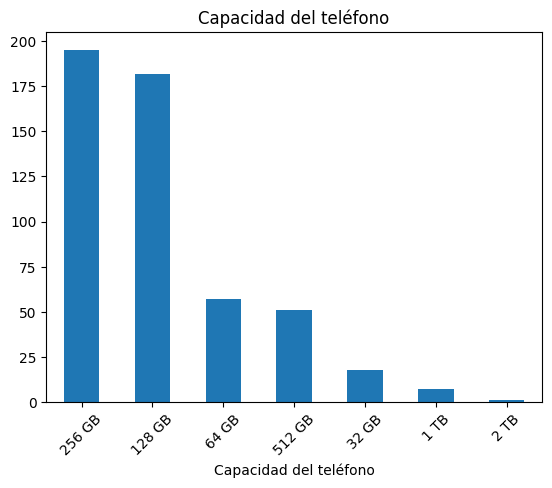

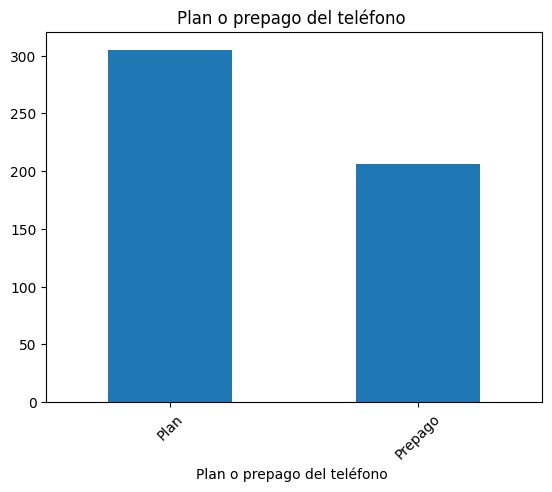

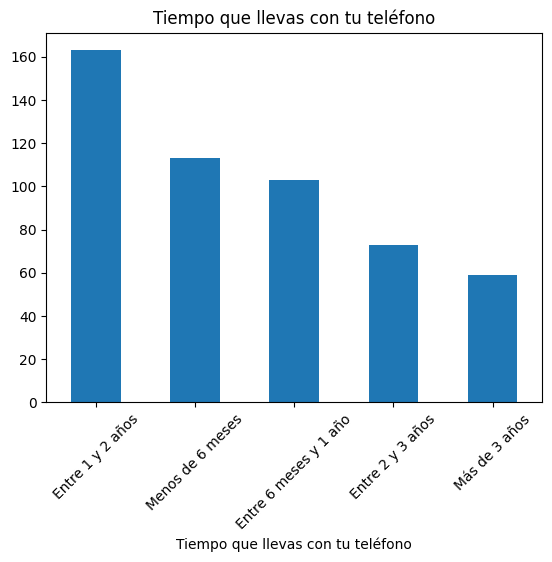

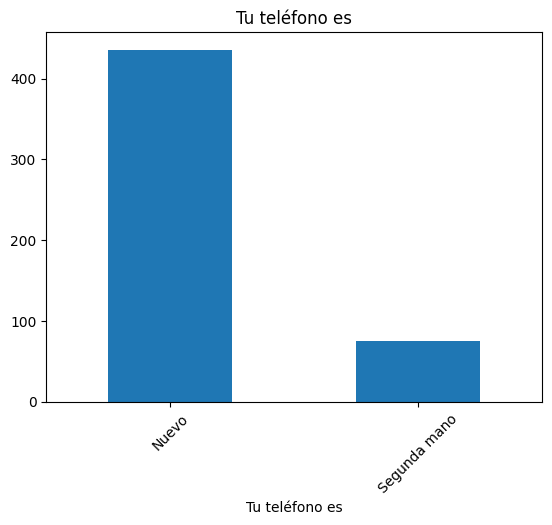

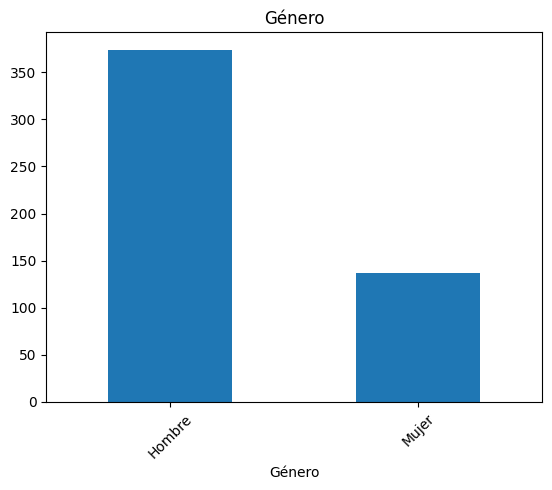

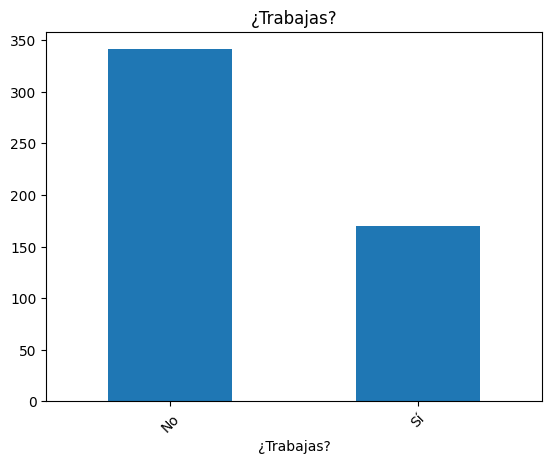

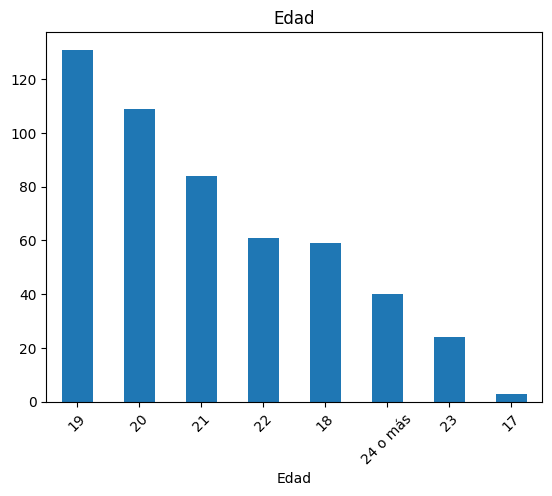

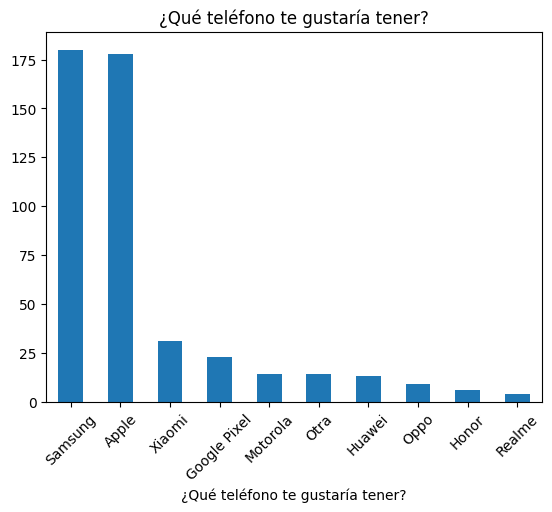

In [60]:
cat_df = df.select_dtypes(exclude='number')

for col in cat_df.columns:
    plt.figure()
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

**LIMPIEZA DE DATOS**

In [61]:
df_clean = df.copy()

# eliminar filas vacías
df_clean = df_clean.dropna(how='all')

# eliminar correo
df_clean = df_clean.drop(columns=["Dirección de correo electrónico"], errors='ignore')

# renombrar columnas
df_clean = df_clean.rename(columns={
    "¿Cuál es la marca de tu teléfono?": "Marca",
    "Capacidad del teléfono": "Capacidad"
})

# edad
df_clean["Edad"] = pd.to_numeric(df_clean["Edad"], errors='coerce')
df_clean["Edad"] = df_clean["Edad"].fillna(df_clean["Edad"].median())

**TRANSFORMACIÓN**

In [62]:
# capacidad numérica
df_clean["Capacidad_num"] = df_clean["Capacidad"].str.extract(r'(\d+)')
df_clean["Capacidad_num"] = pd.to_numeric(df_clean["Capacidad_num"], errors='coerce')

df_clean["Capacidad_num"] = df_clean["Capacidad_num"].fillna(df_clean["Capacidad_num"].median())

# edad num
df_clean["Edad_num"] = df_clean["Edad"]

In [63]:
# grupo edad
df_clean["GrupoEdad"] = pd.cut(
    df_clean["Edad"],
    bins=[15,18,21,25,30],
    labels=["16-18","19-21","22-25","26+"]
)

# alta capacidad
df_clean["AltaCapacidad"] = df_clean["Capacidad_num"] >= 256

**EDA DESPUÉS DE LIMPIEZA**

In [64]:
df_clean[["Edad_num","Capacidad_num"]].describe()

,Edad_num,Capacidad_num
count,511.000000,511.000000
mean,20.039139,202.663405
std,1.355611,128.296853
min,17.000000,1.000000
25%,19.000000,128.000000
50%,20.000000,128.000000
75%,21.000000,256.000000
max,23.000000,512.000000


In [65]:
df_clean[["Edad_num","Capacidad_num"]].cov()

,Edad_num,Capacidad_num
Edad_num,1.837681,2.962219
Capacidad_num,2.962219,16460.082560


In [66]:
df_clean[["Edad_num","Capacidad_num"]].corr()

,Edad_num,Capacidad_num
Edad_num,1.000000,0.017032
Capacidad_num,0.017032,1.000000
